In [1]:
# Filepath imports
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score
from sklearn.svm import SVR

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

from scipy.interpolate import UnivariateSpline

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [2]:
# On log data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_val['age_bin']=pd.cut(
    abs_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_val['age_bin']=pd.cut(
    rel_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']


# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

/tmp/ipykernel_12816/3209011331.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_12816/3209011331.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [3]:
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_aug, abs_Y_train)

# Validation Set
abs_rf_val_preds = abs_rf_reg.predict(abs_X_val_aug)
abs_rf_reg_val_r2 = r2_score(abs_Y_val, abs_rf_val_preds)
abs_rf_reg_val_rmse = np.sqrt(mean_squared_error(abs_Y_val, abs_rf_val_preds))
abs_rf_reg_val_mae = mean_absolute_error(abs_Y_val, abs_rf_val_preds)
print("Validation R²:", abs_rf_reg_val_r2)
print("Validation RMSE:", abs_rf_reg_val_rmse)
print("Validation MAE:", abs_rf_reg_val_mae)

# Test Set
abs_rf_test_preds = abs_rf_reg.predict(abs_X_test_aug)
abs_rf_reg_test_r2 = r2_score(abs_Y_test, abs_rf_test_preds)
abs_rf_reg_test_rmse = np.sqrt(mean_squared_error(abs_Y_test, abs_rf_test_preds))
abs_rf_reg_test_mae = mean_absolute_error(abs_Y_test, abs_rf_test_preds)
print("Test R²:", abs_rf_reg_test_r2)
print("Test RMSE:", abs_rf_reg_test_rmse)
print("Test MAE:", abs_rf_reg_val_mae)

Validation R²: 0.25602295917192763
Validation RMSE: 13.964814974439912
Validation MAE: 11.767889763779529
Test R²: 0.30228923289962073
Test RMSE: 13.523546306605809
Test MAE: 11.767889763779529


In [4]:
# Relative
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train_aug, rel_Y_train)

# Validation Set
rel_rf_val_preds = rel_rf_reg.predict(rel_X_val_aug)
rel_rf_reg_val_r2 = r2_score(rel_Y_val, rel_rf_val_preds)
rel_rf_reg_val_rmse = np.sqrt(mean_squared_error(rel_Y_val, rel_rf_val_preds))
rel_rf_reg_val_mae = mean_absolute_error(rel_Y_val, rel_rf_val_preds)
print("Validation R²:", rel_rf_reg_val_r2)
print("Validation RMSE:", rel_rf_reg_val_rmse)
print("Validation MAE:", rel_rf_reg_val_mae)

# Test Set
rel_rf_test_preds = rel_rf_reg.predict(rel_X_test_aug)
rel_rf_reg_test_r2 = r2_score(rel_Y_test, rel_rf_test_preds)
rel_rf_reg_test_rmse = np.sqrt(mean_squared_error(rel_Y_test, rel_rf_test_preds))
rel_rf_reg_test_mae = mean_absolute_error(rel_Y_test, rel_rf_test_preds)
print("Test R²:", rel_rf_reg_test_r2)
print("Test RMSE:", rel_rf_reg_test_rmse)
print("Test MAE:", rel_rf_reg_val_mae)

Validation R²: 0.2939065852394216
Validation RMSE: 13.604622634434659
Validation MAE: 11.377406824146982
Test R²: 0.31090393254449944
Test RMSE: 13.439798752815665
Test MAE: 11.377406824146982


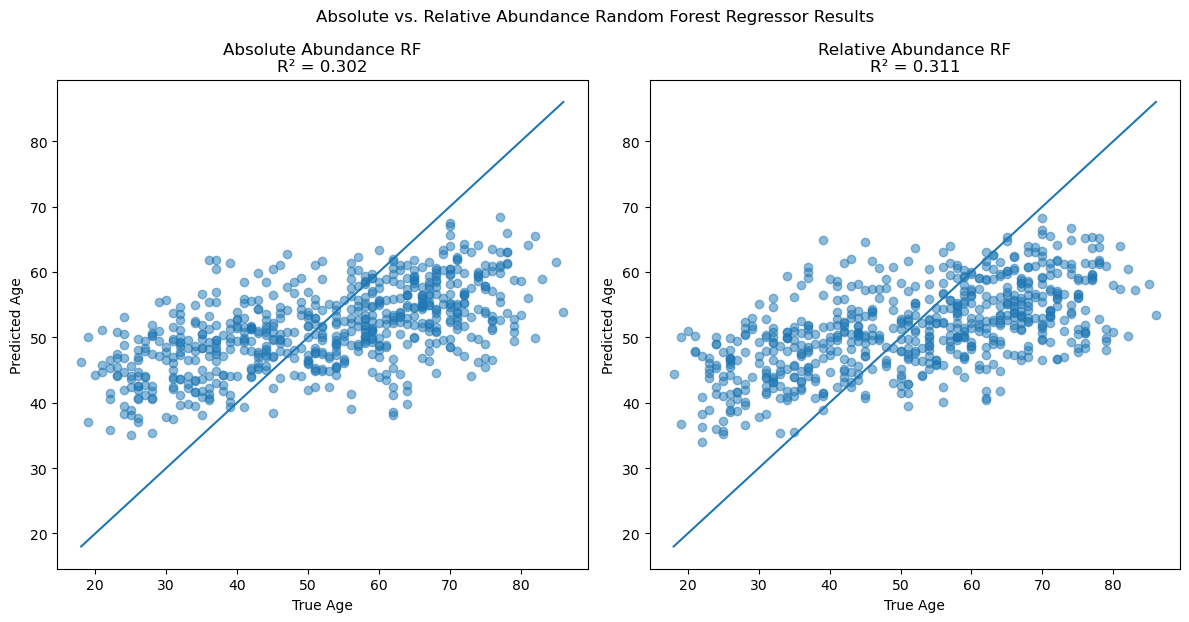

In [5]:
# Plotting the results
r2_abs = r2_score(abs_Y_test, abs_rf_test_preds)
r2_rel = r2_score(rel_Y_test, rel_rf_test_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

min_val = min(abs_Y_test.min(), rel_Y_test.min())
max_val = max(abs_Y_test.max(), rel_Y_test.max())
x_line = np.linspace(min_val, max_val, 100)

# Absolute
axes[0].scatter(abs_Y_test, abs_rf_test_preds, alpha=0.5)
axes[0].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[0].set_title(f"Absolute Abundance RF\nR² = {r2_abs:.3f}")
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")

# Relative
axes[1].scatter(rel_Y_test, rel_rf_test_preds, alpha=0.5)
axes[1].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[1].set_title(f"Relative Abundance RF\nR² = {r2_rel:.3f}")
axes[1].set_xlabel("True Age")
axes[1].set_ylabel("Predicted Age")

plt.tight_layout()
fig.suptitle("Absolute vs. Relative Abundance Random Forest Regressor Results", y=1.03)
plt.savefig("rf_reg_comparison.png", format="png")
plt.show()

In [6]:
# Bootstrapping to see if differences are due to chance
n_boot = 5000
rng = np.random.default_rng(42)

diffs = []

n = len(abs_Y_test)

for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    
    y_sample = abs_Y_test.iloc[idx]
    abs_sample = abs_rf_test_preds[idx]
    rel_sample = rel_rf_test_preds[idx]
    
    r2_abs = r2_score(y_sample, abs_sample)
    r2_rel = r2_score(y_sample, rel_sample)
    
    diffs.append(r2_rel - r2_abs)

diffs = np.array(diffs)

ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("Mean ΔR²:", mean_diff)
print("95% CI:", ci_lower, "to", ci_upper)

Mean ΔR²: 0.008530877938923322
95% CI: -0.012746292606920026 to 0.02982046966380093


In [7]:
p_value = np.mean(diffs <= 0)
print("P-value:", p_value)

P-value: 0.2212


# Gradient Boosting

In [8]:
# Initialize model
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Fit
abs_gbr = gbr.fit(abs_X_train_aug, abs_Y_train)

# Validation Set
y_pred = abs_gbr.predict(abs_X_val_aug)
abs_gbr_val_r2 = r2_score(abs_Y_val, y_pred)
abs_gbr_val_rmse = np.sqrt(mean_squared_error(abs_Y_val, y_pred))
abs_gbr_val_mae = mean_absolute_error(abs_Y_val, y_pred)
print("Validation R²:", abs_gbr_val_r2)
print("Validation RMSE:", abs_gbr_val_rmse)
print("Validation MAE:", abs_gbr_val_mae)

# Test Set
y_pred = abs_gbr.predict(abs_X_test_aug)
abs_gbr_test_r2 = r2_score(abs_Y_test, y_pred)
abs_gbr_test_rmse = np.sqrt(mean_squared_error(abs_Y_test, y_pred))
abs_gbr_test_mae = mean_absolute_error(abs_Y_test, y_pred)
print("Test R²:", abs_gbr_test_r2)
print("Test RMSE:", abs_gbr_test_rmse)
print("Test MAE:", abs_gbr_val_mae)

Validation R²: 0.3670506458795798
Validation RMSE: 12.880712883917758
Validation MAE: 10.633318061413876
Test R²: 0.3902137612384713
Test RMSE: 12.642754056459774
Test MAE: 10.633318061413876


In [9]:
# Fit
# Relative
rel_gbr = gbr.fit(rel_X_train_aug, rel_Y_train)

# Validation Set
y_pred = rel_gbr.predict(rel_X_val_aug)
rel_gbr_val_r2 = r2_score(rel_Y_val, y_pred)
rel_gbr_val_rmse = np.sqrt(mean_squared_error(rel_Y_val, y_pred))
rel_gbr_val_mae = mean_absolute_error(rel_Y_val, y_pred)
print("Validation R²:", rel_gbr_val_r2)
print("Validation RMSE:", rel_gbr_val_rmse)
print("Validation MAE:", rel_gbr_val_mae)

# Test Set
y_pred = rel_gbr.predict(rel_X_test_aug)
rel_gbr_test_r2 = r2_score(rel_Y_test, y_pred)
rel_gbr_test_mae = mean_absolute_error(rel_Y_test, y_pred)
rel_gbr_test_rmse = np.sqrt(mean_squared_error(rel_Y_test, y_pred))
print("Test R²:", rel_gbr_test_r2)
print("Test RMSE:", rel_gbr_test_rmse)
print("Test MAE:", rel_gbr_test_mae)

Validation R²: 0.40646326062088134
Validation RMSE: 12.473238384101794
Validation MAE: 10.14465966410126
Test R²: 0.404796400338132
Test RMSE: 12.490667695460015
Test MAE: 10.188036023719647


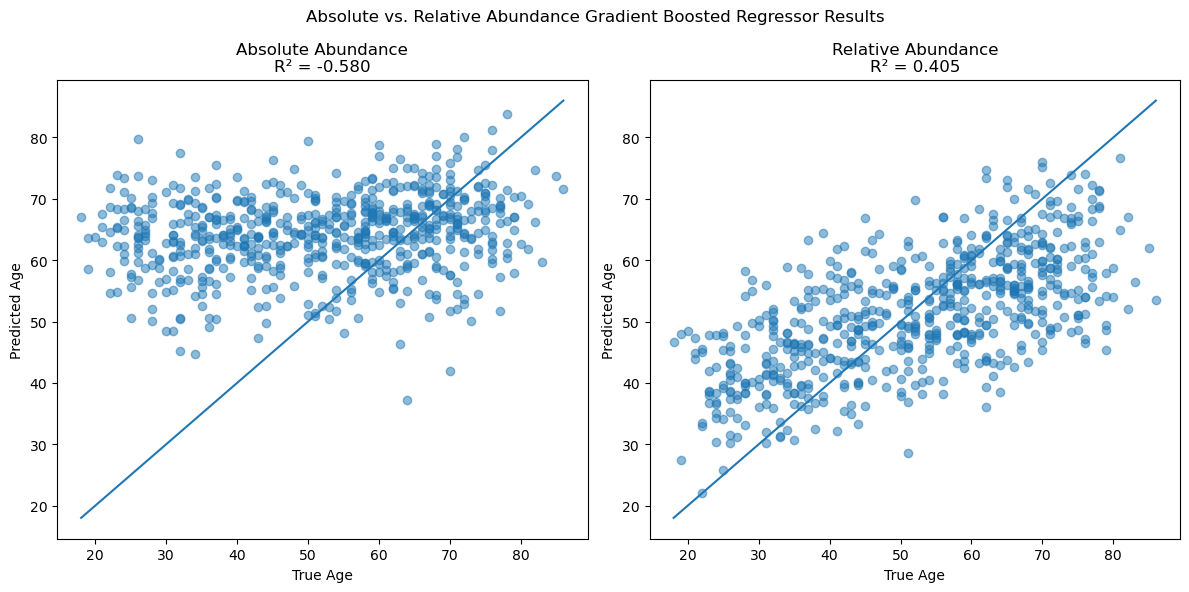

In [10]:
# Plotting the results
abs_pred = abs_gbr.predict(abs_X_test_aug)
rel_pred = rel_gbr.predict(rel_X_test_aug)

r2_abs = r2_score(abs_Y_test, abs_pred)
r2_rel = r2_score(rel_Y_test, rel_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

min_val = min(abs_Y_test.min(), rel_Y_test.min())
max_val = max(abs_Y_test.max(), rel_Y_test.max())
x_line = np.linspace(min_val, max_val, 100)

fig.suptitle("Absolute vs. Relative Abundance Gradient Boosted Regressor Results")

# Absolute
axes[0].scatter(abs_Y_test, abs_pred, alpha=0.5)
axes[0].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[0].set_title(f"Absolute Abundance\nR² = {r2_abs:.3f}")
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")

# Relative
axes[1].scatter(rel_Y_test, rel_pred, alpha=0.5)
axes[1].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[1].set_title(f"Relative Abundance\nR² = {r2_rel:.3f}")
axes[1].set_xlabel("True Age")
axes[1].set_ylabel("Predicted Age")

plt.tight_layout()
plt.savefig("gbr_comparison.png",format="png")
plt.show()

In [11]:
# Bootstrapping to see if differences are due to chance
n_boot = 5000
rng = np.random.default_rng(42)

diffs = []

n = len(abs_Y_test)

for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    
    y_sample = abs_Y_test.iloc[idx]
    abs_sample = abs_pred[idx]
    rel_sample = rel_pred[idx]
    
    r2_abs = r2_score(y_sample, abs_sample)
    r2_rel = r2_score(y_sample, rel_sample)
    
    diffs.append(r2_rel - r2_abs)

diffs = np.array(diffs)

ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("Mean ΔR²:", mean_diff)
print("95% CI:", ci_lower, "to", ci_upper)
p_value = np.mean(diffs <= 0)
print("P-value:", p_value)

Mean ΔR²: 0.9873289438669169
95% CI: 0.846289097578488 to 1.134447839598046
P-value: 0.0


# SVM RBF

In [12]:
# Absolute
# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__gamma": ["scale", 0.01, 0.1, 1],
    "svr__epsilon": [0.01, 0.1, 0.5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search.fit(abs_X_train_aug, abs_Y_train)
abs_best_svr = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# Validation Set
y_pred = abs_best_svr.predict(abs_X_val_aug)
abs_svm_val_r2 = r2_score(abs_Y_val, y_pred)
abs_svm_val_rmse = np.sqrt(mean_squared_error(abs_Y_val, y_pred))
abs_svm_val_mae = mean_absolute_error(abs_Y_val, y_pred)
print("Validation MAE:", abs_svm_val_mae)
print("Validation R²:", abs_svm_val_r2)
print("Validation RMSE:", abs_svm_val_rmse)

# Test Set
abs_svr_pred = abs_best_svr.predict(abs_X_test_aug)
abs_svm_test_r2 = r2_score(abs_Y_test, abs_svr_pred)
abs_svm_test_rmse = np.sqrt(mean_squared_error(abs_Y_test, abs_svr_pred))
abs_svm_test_mae = mean_absolute_error(abs_Y_test, abs_svr_pred)
print("Test MAE:", abs_svm_val_mae)
print("Test R²:", abs_svm_test_r2)
print("Test RMSE:", abs_svm_test_rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.5, 'svr__gamma': 'scale'}
Best CV R²: -10.151596102247106
Validation MAE: 9.954169783715724
Validation R²: 0.4199336354739983
Validation RMSE: 12.330885382095932
Test MAE: 9.954169783715724
Test R²: 0.43849806280247206
Test RMSE: 12.131891270256268


In [13]:
# Relative
# Fit
grid_search.fit(rel_X_train_aug, rel_Y_train)
rel_best_svr = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# Validation Set
y_pred = rel_best_svr.predict(rel_X_val_aug)
rel_svm_val_r2 = r2_score(rel_Y_val, y_pred)
rel_svm_val_rmse = np.sqrt(mean_squared_error(rel_Y_val, y_pred))
rel_svm_val_mae = mean_absolute_error(abs_Y_val, y_pred)
print("Validation R²:", rel_svm_val_r2)
print("Validation RMSE:", rel_svm_val_rmse)
print("Validation MAE:", rel_svm_val_mae)

# Test Set
rel_svr_pred = abs_gbr.predict(rel_X_test_aug)
rel_svm_test_r2 = r2_score(rel_Y_test, rel_svr_pred)
rel_svm_test_rmse = np.sqrt(mean_squared_error(rel_Y_test, rel_svr_pred))
rel_svm_test_mae = mean_absolute_error(abs_Y_test, rel_svr_pred)
print("Test R²:", rel_svm_test_r2)
print("Test RMSE:", rel_svm_test_rmse)
print("Validation MAE:", rel_svm_test_mae)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV R²: -9.404549633424827
Validation R²: 0.505460471043957
Validation RMSE: 11.385600067662565
Validation MAE: 9.047840031331093
Test R²: 0.404796400338132
Test RMSE: 12.490667695460015
Validation MAE: 10.188036023719647


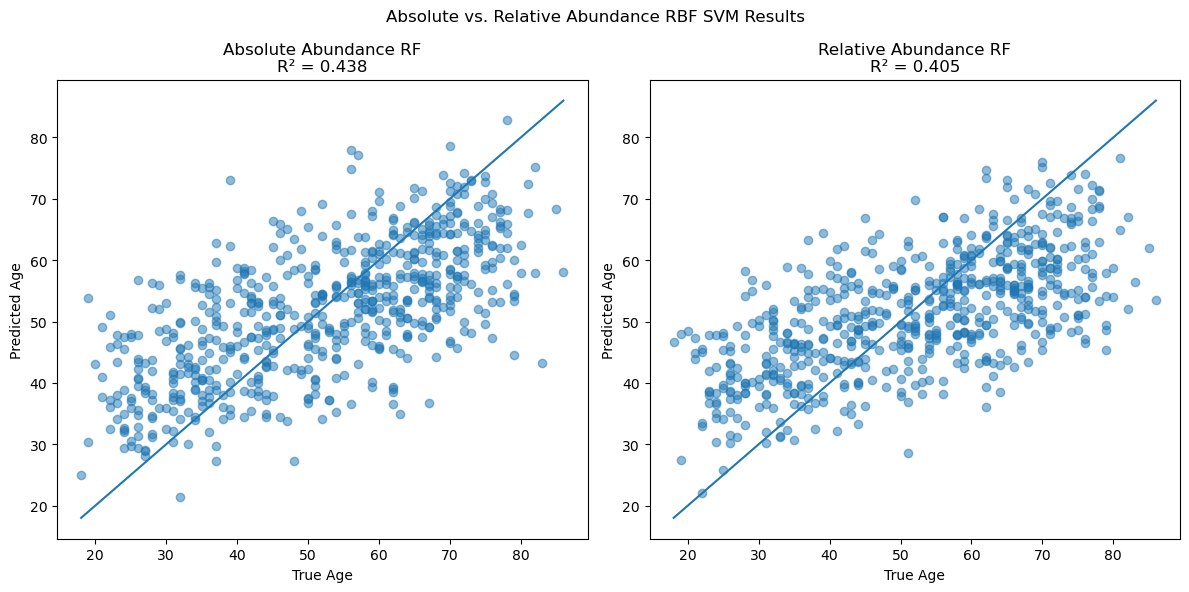

In [14]:
# Plotting the results
r2_abs = r2_score(abs_Y_test, abs_svr_pred)
r2_rel = r2_score(rel_Y_test, rel_svr_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

min_val = min(abs_Y_test.min(), rel_Y_test.min())
max_val = max(abs_Y_test.max(), rel_Y_test.max())
x_line = np.linspace(min_val, max_val, 100)

# Absolute
axes[0].scatter(abs_Y_test, abs_svr_pred, alpha=0.5)
axes[0].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[0].set_title(f"Absolute Abundance RF\nR² = {r2_abs:.3f}")
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")

# Relative
axes[1].scatter(rel_Y_test, rel_svr_pred, alpha=0.5)
axes[1].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[1].set_title(f"Relative Abundance RF\nR² = {r2_rel:.3f}")
axes[1].set_xlabel("True Age")
axes[1].set_ylabel("Predicted Age")

fig.suptitle("Absolute vs. Relative Abundance RBF SVM Results")
plt.savefig('rbf_comparison.png', format="png")

plt.tight_layout()
plt.show()

In [15]:
# Bootstrapping to see if differences are due to chance
n_boot = 5000
rng = np.random.default_rng(42)

diffs = []

n = len(abs_Y_test)

for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    
    y_sample = abs_Y_test.iloc[idx]
    abs_sample = abs_svr_pred[idx]
    rel_sample = rel_svr_pred[idx]
    
    r2_abs = r2_score(y_sample, abs_sample)
    r2_rel = r2_score(y_sample, rel_sample)
    
    diffs.append(r2_rel - r2_abs)

diffs = np.array(diffs)

ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("Mean ΔR²:", mean_diff)
print("95% CI:", ci_lower, "to", ci_upper)
p_value = np.mean(diffs <= 0)
print("P-value:", p_value)

Mean ΔR²: -0.03343735524711525
95% CI: -0.08002005826038672 to 0.012917502850633845
P-value: 0.9234


# Seeing if adding taxa helps

In [16]:
tax = pd.read_csv('/ddn_scratch/miter/nph-tables/wolr2-taxonomy.tsv', sep='\t')
tax['genus_raw'] = tax['d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales_H; f__Bacillaceae_D; g__Bacillus_S; s__Bacillus_S pseudofirmus'].str.extract(r'g__([^;]+)')
age_bac = ['Haemophilus_D', 'Sutterella', 'Akkermansia', 'Phascolarctobacterium', 
           'Ruminiclostridium_E', 'Cloacibacillus', 'Pseudomonas', 'UBA1685', 
           'UBA10677', 'CAG-314', 'CAG-313', 'QAKW01']

# Retrieving column names from taxonomy mapping with values in age_bac
tax_rel_bac = tax[tax["genus_raw"].isin(age_bac)].copy()
col_names = tax_rel_bac['G000005825'].values

In [17]:
# Filtering train/test/val datasets to only use these columns
# Absolute quant
abs_X_train = abs_balanced_train.loc[:, abs_balanced_train.columns.isin(col_names)].copy()
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test.loc[:, abs_test.columns.isin(col_names)].copy()
abs_Y_test  = abs_test['age']

abs_X_val = abs_val.loc[:, abs_val.columns.isin(col_names)].copy()
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train.loc[:, rel_balanced_train.columns.isin(col_names)].copy()
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test.loc[:, rel_test.columns.isin(col_names)].copy()
rel_Y_test  = rel_test['age']

rel_X_val = rel_val.loc[:, rel_val.columns.isin(col_names)].copy()
rel_Y_val  = rel_val['age']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

In [18]:
# Absolute
abs_rf_taxa = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_taxa.fit(abs_X_train_aug, abs_Y_train)

# Validation Set
abs_rf_taxa_val_pred = abs_rf_taxa.predict(abs_X_val_aug)
abs_rf_taxa_val_r2 = r2_score(abs_Y_val, y_pred)
abs_rf_taxa_val_rmse = np.sqrt(mean_squared_error(abs_Y_val, abs_rf_taxa_val_pred))
abs_rf_taxa_val_mae = mean_absolute_error(abs_Y_val, abs_rf_taxa_val_pred)
print("Validation MAE:", abs_rf_taxa_val_mae)
print("Validation R²:", abs_rf_taxa_val_r2)
print("Validation RMSE:", abs_rf_taxa_val_rmse)

# Test Set
abs_rf_taxa_test_pred = abs_rf_taxa.predict(abs_X_test_aug)
abs_rf_taxa_test_r2 = r2_score(abs_Y_test, abs_rf_taxa_test_pred)
abs_rf_taxa_test_rmse = np.sqrt(mean_squared_error(abs_Y_test, abs_rf_taxa_test_pred))
abs_rf_taxa_test_mae = mean_absolute_error(abs_Y_test, abs_rf_taxa_test_pred)
print("Test R²:", abs_rf_taxa_test_r2)
print("Test RMSE:", abs_rf_taxa_test_rmse)
print("Test MAE:", abs_rf_taxa_val_mae)

Validation MAE: 12.66602624671916
Validation R²: 0.505460471043957
Validation RMSE: 15.02968513095361
Test R²: 0.16108593710049368
Test RMSE: 14.828991533606121
Test MAE: 12.66602624671916


In [19]:
# Relative
rel_rf_taxa = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_taxa.fit(rel_X_train_aug, rel_Y_train)

# Validation Set
rel_rf_taxa_val_pred = rel_rf_taxa.predict(rel_X_val_aug)
rel_rf_taxa_val_r2 = r2_score(rel_Y_val, rel_rf_taxa_val_pred)
rel_rf_taxa_val_rmse = np.sqrt(mean_squared_error(rel_Y_val, rel_rf_taxa_val_pred))
rel_rf_taxa_val_mae = mean_absolute_error(rel_Y_val, rel_rf_taxa_val_pred)
print("Validation MAE:", rel_rf_taxa_val_mae)
print("Validation R²:", rel_rf_taxa_val_r2)
print("Validation RMSE:", rel_rf_taxa_val_rmse)

# Test Set
rel_rf_taxa_test_pred = rel_rf_taxa.predict(abs_X_test_aug)
rel_rf_taxa_test_r2 = r2_score(rel_Y_test, rel_rf_taxa_test_pred)
rel_rf_taxa_test_rmse = np.sqrt(mean_squared_error(rel_Y_test, rel_rf_taxa_test_pred))
rel_rf_taxa_test_mae = mean_absolute_error(rel_Y_test, rel_rf_taxa_test_pred)
print("Test R²:", rel_rf_taxa_test_r2)
print("Test RMSE:", rel_rf_taxa_test_rmse)
print("Test MAE:", rel_rf_taxa_val_mae)

Validation MAE: 12.350839895013122
Validation R²: 0.17022928057044706
Validation RMSE: 14.748045609210006
Test R²: -0.08651865548603688
Test RMSE: 16.876076045016074
Test MAE: 12.350839895013122


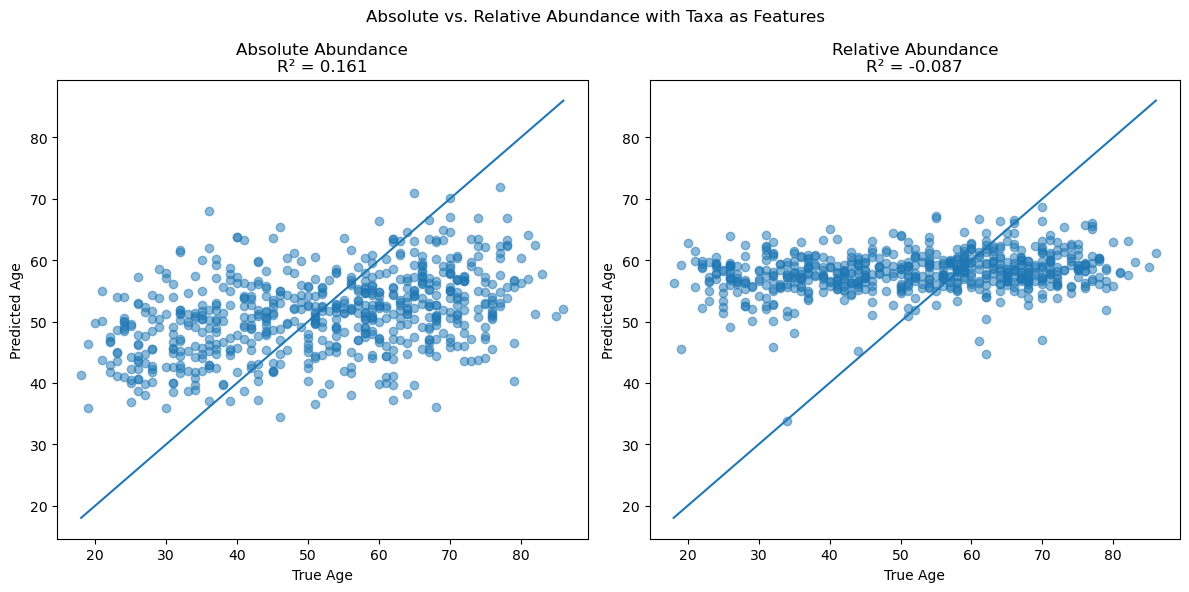

In [20]:
# Plotting the results
abs_pred = abs_rf_taxa.predict(abs_X_test_aug)
rel_pred = rel_rf_taxa.predict(rel_X_test_aug)

r2_abs = r2_score(abs_Y_test, abs_rf_taxa_test_pred)
r2_rel = r2_score(rel_Y_test, rel_rf_taxa_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

min_val = min(abs_Y_test.min(), rel_Y_test.min())
max_val = max(abs_Y_test.max(), rel_Y_test.max())
x_line = np.linspace(min_val, max_val, 100)

# Absolute
axes[0].scatter(abs_Y_test, abs_rf_taxa_test_pred, alpha=0.5)
axes[0].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[0].set_title(f"Absolute Abundance\nR² = {r2_abs:.3f}")
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")

# Relative
axes[1].scatter(rel_Y_test, rel_rf_taxa_test_pred, alpha=0.5)
axes[1].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[1].set_title(f"Relative Abundance\nR² = {r2_rel:.3f}")
axes[1].set_xlabel("True Age")
axes[1].set_ylabel("Predicted Age")

fig.suptitle('Absolute vs. Relative Abundance with Taxa as Features')
plt.tight_layout()
plt.savefig("rf_taxa_comparison.png",format="png")
plt.show()

In [21]:
# Bootstrapping to see if differences are due to chance
n_boot = 5000
rng = np.random.default_rng(42)

diffs = []

n = len(abs_Y_test)

for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    
    y_sample = abs_Y_test.iloc[idx]
    abs_sample = abs_rf_taxa_test_pred[idx]
    rel_sample = rel_rf_taxa_test_pred[idx]
    
    r2_abs = r2_score(y_sample, abs_sample)
    r2_rel = r2_score(y_sample, rel_sample)
    
    diffs.append(r2_rel - r2_abs)

diffs = np.array(diffs)

ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("Mean ΔR²:", mean_diff)
print("95% CI:", ci_lower, "to", ci_upper)
p_value = np.mean(diffs <= 0)
print("P-value:", p_value)

Mean ΔR²: -0.24842073812864038
95% CI: -0.33046280365732045 to -0.16725883483068776
P-value: 1.0


In [22]:
# Creating the table
task = ['Regression', 'Regression', 'Regression', 'Regression', 'Regression', 'Regression', 'Regression', 'Regression']
target = ['age', 'age', 'age', 'age', 'age', 'age', 'age', 'age',]
representation = ['Absolute', 'Absolute', 'Absolute', 'Absolute', 'Relative', 'Relative', 'Relative', 'Relative']
model = ['RandomForest', 'GBR', 'SVM_RBF', 'RandomForest', 'RandomForest', 'GBR', 'SVM_RBF', 'RandomForest']
valMAE = [abs_rf_reg_val_mae, abs_gbr_val_mae, abs_svm_val_mae, abs_rf_taxa_val_mae, rel_rf_reg_val_mae, rel_gbr_val_mae, rel_svm_val_mae, rel_rf_taxa_val_mae]
testMAE = valMAE = [abs_rf_reg_test_mae, abs_gbr_test_mae, abs_svm_test_mae, abs_rf_taxa_test_mae, rel_rf_reg_test_mae, rel_gbr_test_mae, rel_svm_test_mae, rel_rf_taxa_test_mae]
valR2 = [abs_rf_reg_val_r2, abs_gbr_val_r2, abs_svm_val_r2, abs_rf_taxa_val_r2, rel_rf_reg_val_r2, rel_gbr_val_r2, rel_svm_val_r2, rel_rf_taxa_val_r2]
testR2 = [abs_rf_reg_test_r2, abs_gbr_test_r2, abs_svm_test_r2, abs_rf_taxa_test_r2, rel_rf_reg_test_r2, rel_gbr_test_r2, rel_svm_test_r2, rel_rf_taxa_test_r2]
valRMSE = [abs_rf_reg_val_rmse, abs_gbr_val_rmse, abs_svm_val_rmse, abs_rf_taxa_val_rmse, rel_rf_reg_val_rmse, rel_gbr_val_rmse, rel_svm_val_rmse, rel_rf_taxa_val_rmse]
testRMSE = [abs_rf_reg_test_rmse, abs_gbr_test_rmse, abs_svm_test_rmse, abs_rf_taxa_test_rmse, rel_rf_reg_test_rmse, rel_gbr_test_rmse, rel_svm_test_rmse, rel_rf_taxa_test_rmse]

results_df = pd.DataFrame({
    'Task': task,
    'Target': target,
    'Representation': representation,
    'Model': model,
    'Val_MAE': valMAE,
    'Test_MAE': testMAE,
    'Val_R2': valR2,
    'Test_R2': testR2,
    'Val_RMSE': valRMSE,
    'Test_RMSE': testRMSE
})

results_df = results_df.round(6)
results_df

,Task,Target,Representation,Model,Val_MAE,Test_MAE,Val_R2,Test_R2,Val_RMSE,Test_RMSE
0,Regression,age,Absolute,RandomForest,11.458184,11.458184,0.256023,0.302289,13.964815,13.523546
1,Regression,age,Absolute,GBR,10.281309,10.281309,0.367051,0.390214,12.880713,12.642754
2,Regression,age,Absolute,SVM_RBF,9.762966,9.762966,0.419934,0.438498,12.330885,12.131891
3,Regression,age,Absolute,RandomForest,12.491554,12.491554,0.505460,0.161086,15.029685,14.828992
4,Regression,age,Relative,RandomForest,11.355181,11.355181,0.293907,0.310904,13.604623,13.439799
5,Regression,age,Relative,GBR,10.188036,10.188036,0.406463,0.404796,12.473238,12.490668
6,Regression,age,Relative,SVM_RBF,10.188036,10.188036,0.505460,0.404796,11.385600,12.490668
7,Regression,age,Relative,RandomForest,13.770625,13.770625,0.170229,-0.086519,14.748046,16.876076


In [23]:
results_df.to_csv("age_reg_model_comparisons.csv", index=False)